# Helmet Detection System

### Get Started

####  1. Load Packages

In [2]:
import os
import yaml
import shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import xml.etree.ElementTree as ET
from xml.dom.minidom import parse
from IPython.display import Image
from sklearn.model_selection import train_test_split

####  2. Explore Data

In [3]:
img_file = 'hard_hat_workers2.png'
annot_file = 'hard_hat_workers2.xml'
images_path = 'HelmetDetection/images'
annot_path = 'HelmetDetection/annotations'

In [4]:
xml_data = open(os.path.join(annot_path, annot_file), 'r').read()
print(xml_data)


<annotation>
    <folder>images</folder>
    <filename>hard_hat_workers2.png</filename>
    <size>
        <width>416</width>
        <height>415</height>
        <depth>3</depth>
    </size>
    <segmented>0</segmented>
    <object>
        <name>helmet</name>
        <pose>Unspecified</pose>
        <truncated>0</truncated>
        <occluded>0</occluded>
        <difficult>0</difficult>
        <bndbox>
            <xmin>329</xmin>
            <ymin>216</ymin>
            <xmax>360</xmax>
            <ymax>245</ymax>
        </bndbox>
    </object>
    <object>
        <name>helmet</name>
        <pose>Unspecified</pose>
        <truncated>0</truncated>
        <occluded>0</occluded>
        <difficult>0</difficult>
        <bndbox>
            <xmin>298</xmin>
            <ymin>222</ymin>
            <xmax>323</xmax>
            <ymax>251</ymax>
        </bndbox>
    </object>
</annotation>


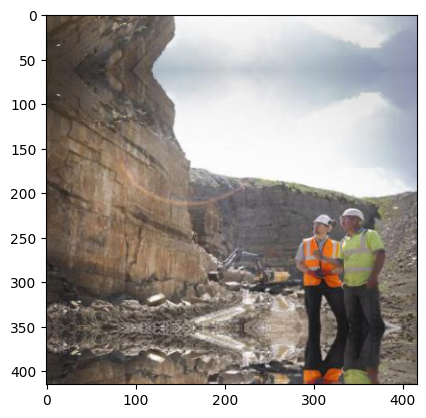

In [5]:
img = plt.imread(os.path.join(images_path, img_file))
plt.imshow(img)

####  3. Preview Labeled Data

In [6]:
def plot_box(image_file, annotation_file):
    # Load the image
    image = plt.imread(image_file)

    # Create figure and axes
    fig, ax = plt.subplots(1)

    # Display the image
    ax.imshow(image)

    # Parse the XML annotation file
    tree = ET.parse(annotation_file)
    root = tree.getroot()

    # Iterate over each object in the annotation
    for obj in root.findall('object'):
        # Get the object label
        label = obj.find('name').text

        # Get the bounding box coordinates
        xmin = int(obj.find('bndbox/xmin').text)
        ymin = int(obj.find('bndbox/ymin').text)
        xmax = int(obj.find('bndbox/xmax').text)
        ymax = int(obj.find('bndbox/ymax').text)

        # Create a rectangle patch
        rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=2, edgecolor='r', facecolor='none')

        # Add the rectangle patch to the axes
        ax.add_patch(rect)

        # Add the label as text
        ax.text(xmin, ymin, label, fontsize=7, color='r', verticalalignment='baseline', bbox={'facecolor': 'white', 'alpha': 0.5, 'pad': 1})

    # Show the plot
    plt.show()

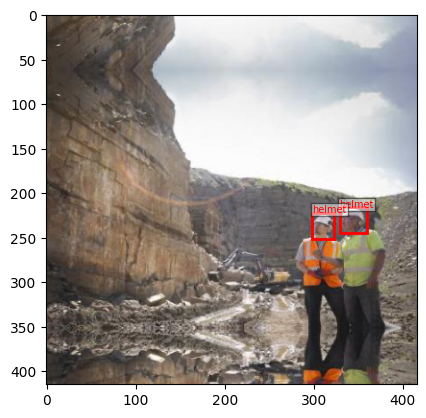

In [7]:
# Function call
plot_box(os.path.join(images_path, img_file), os.path.join(annot_path, annot_file))

### Data Preparation

####  4. Split The Data

In [8]:
images_names = os.listdir(images_path)

In [9]:
train_lst, test_lst = train_test_split(images_names, test_size=0.2, shuffle=True, random_state=10)
train_lst, val_lst = train_test_split(train_lst, test_size=0.15, shuffle=True, random_state=10)


In [10]:
print("Train set size: ", len(train_lst))
print("Test set size: ", len(test_lst))
print("Validation set size: ", len(val_lst))

Train set size:  3400
Test set size:  1000
Validation set size:  600


#### 5. Copy Images

In [11]:
def copy_files(file_list, source_folder, target_folder):
    # create needed directories
    os.makedirs(target_folder, exist_ok=True)
    for file in file_list:
        # copy image to the target folder
        shutil.copy(os.path.join(source_folder, file), target_folder)

In [12]:
# Copy files to train, val, and test directories
copy_files(train_lst, images_path, os.path.join(images_path, 'train'))
copy_files(val_lst, images_path, os.path.join(images_path, 'val'))
copy_files(test_lst, images_path, os.path.join(images_path, 'test'))

####  6. Create Labels

In [13]:
classes = ['helmet','head','person']

#### 7. Create Configuration File

In [14]:
config = {
   "path": r"/HelmetDetection/images",
   "train": "train",
   "val": "val",
   "test": "test",
   "nc": 3,
   "names": classes
}

In [15]:
with open("/usercode/data.yaml", "w") as file:
       yaml.dump(config, file, default_flow_style=False)

### Create YOLO Annotations

#### 8. Generate the Bounding Box Data

In [16]:
def convert_annot(size , box):
    # Get the four attributes to specified variables
    x1 = int(box[0])
    y1 = int(box[1])
    x2 = int(box[2])
    y2 = int(box[3])
    
    # Calculate the new four attributes 
    w = x2 - x1
    h = y2 - y1
    x = x1 + (w / 2)
    y = y1 + (h / 2)

    # Calculate the normalizing factors
    dw = np.float32(1. / int(size[0]))
    dh = np.float32(1. / int(size[1]))

    # Normalize the calculated values
    x = x * dw
    w = w * dw
    y = y * dh
    h = h * dh

    # Return a list with the new values
    return [x, y, w, h]

#### 9. Write Annotations to Text Files

In [17]:
def save_txt_file(target_path, img_jpg_file_name, size, img_box):
    save_file_name = os.path.join(target_path, f"{img_jpg_file_name}.txt")
    with open(save_file_name, 'a+') as file_path:
        for box in img_box:
            # get the index of the class
            cls_num = classes.index(box[0])
            # calculate the new annotations
            new_box = convert_annot(size, box[1:])
            # write them to a string and append it to the open file
            file_path.write(f"{cls_num} {new_box[0]} {new_box[1]} {new_box[2]} {new_box[3]}\n")

        file_path.flush()
        file_path.close()

#### 10. Parse XML Data

In [18]:
def get_xml_data(file_path, img_xml_file, target_path):
    img_path = os.path.join(file_path, f"{img_xml_file}.xml")
    root = parse(img_path).documentElement
    # get the image size
    img_size = root.getElementsByTagName("size")[0]    
    img_w = img_size.getElementsByTagName("width")[0].childNodes[0].data
    img_h = img_size.getElementsByTagName("height")[0].childNodes[0].data
    
    # get the boxes
    objects = root.getElementsByTagName("object")   
    img_box = []
    for box in objects:
        cls_name = box.getElementsByTagName("name")[0].childNodes[0].data
        x1 = int(box.getElementsByTagName("xmin")[0].childNodes[0].data)
        y1 = int(box.getElementsByTagName("ymin")[0].childNodes[0].data)
        x2 = int(box.getElementsByTagName("xmax")[0].childNodes[0].data)
        y2 = int(box.getElementsByTagName("ymax")[0].childNodes[0].data)
        img_box.append([cls_name, x1, y1, x2, y2])
  
    save_txt_file(target_path, img_xml_file, [img_w, img_h], img_box)

#### 11. Extract XML Annotations for All Data

In [19]:
# Add folder to save the new annotations
labels_path = "/HelmetDetection/labels"
# list of subdirectories for the splits
dirs = ['train', 'val', 'test']

# Change annotations to text files
for folder in dirs:
    img_path = os.path.join(images_path, folder)
    files = os.listdir(img_path)
    target_folder = os.path.join(labels_path, folder)
    os.makedirs(target_folder, exist_ok=True)
    for file in files:
        file_xml = file.split(".")
        get_xml_data(annot_path, file_xml[0], target_folder)

### Modeling

#### 12. Clone the YOLOv5 Repository

In [20]:
!git clone https://github.com/ultralytics/yolov5

Cloning into 'yolov5'...
remote: Enumerating objects: 17960, done.
remote: Counting objects: 100% (104/104), done.
remote: Compressing objects: 100% (76/76), done.
remote: Total 17960 (delta 81), reused 28 (delta 28), pack-reused 17856 (from 3)
Receiving objects: 100% (17960/17960), 17.10 MiB | 7.63 MiB/s, done.
Resolving deltas: 100% (12219/12219), done.


In [21]:
%pip install -r yolov5/requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 888.0/888.0 MB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

#### 13. Train The Model

In [22]:
!python yolov5/train.py --img 128 --batch 16 --epochs 3 --data /usercode/data.yaml --weights /usercode/yolov5s.pt  --name yolov5s_results

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
train: weights=/usercode/yolov5s.pt, cfg=, data=/usercode/data.yaml, hyp=yolov5/data/hyps/hyp.scratch-low.yaml, epochs=3, batch_size=16, imgsz=128, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=yolov5/data/hyps, resume_evolve=None, bucket=, cache=None, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=yolov5/runs/train, name=yolov5s_results, exist_ok=False, quad=False, cos_lr=False, label_smoothing=0.0, patience=100, freeze=[0], save_period=-1, seed=0, local_rank=-1, entity=None, upload_dataset=False, bbox_interval=-1, artifact_alias=latest, nd

### Evaluation and Predition

#### 14. Results Plot

In [ ]:
results_path = r"yolov5/runs/train/yolov5s_results"
res_png = os.path.join(results_path, "results.png")
Image(filename=res_png, width=1000)

NameError: name 'Image' is not defined

#### 15. Run Object Detection on Test Images

In [ ]:
best_weights = os.path.join(results_path, "weights/best.pt")

In [ ]:
test_path = os.path.join(images_path, "test")

In [ ]:
!python yolov5/detect.py --weights {best_weights} --source {test_path} --img 218 --conf 0.4  --name yolov5s_results

#### 16. Preview Detections

In [ ]:
det_path = r"yolov5/runs/detect/yolov5s_results"

for imageName in os.listdir(det_path)[:10]: 
    display(Image(filename=os.path.join(det_path, imageName)))